# Proposed Interaction-Aware LIME Methods
## MTP-2: Beyond Independent Attribution

**Aman Tiwari** (24CS60R35)  
Department of Computer Science and Engineering, IIT Kharagpur  
Supervisor: Prof. Palash Dey

---

This notebook implements and evaluates four interaction-aware extensions of LIME:

| Method | Approach | Cost vs LIME |
|--------|----------|-------------|
| **P-LIME** | Quadratic surrogate with all pairwise interaction terms | ~8× |
| **G-LIME** | Cluster superpixels into groups, LIME on groups, redistribute | ~1.2× |
| **S-LIME** | Monte Carlo Shapley values with antithetic sampling | ~19× |
| **H-LIME** | Multi-scale LIME (coarse + medium + fine) with adaptive weights | ~3.5× |

### Evaluation Metrics
- **General faithfulness**: Deletion AUC (↓), Insertion AUC (↑)
- **Interaction-specific**: Sign Agreement (↑), Top-K Overlap (↑), Interaction Fidelity (↓)

In [1]:
!pip install -q lime scikit-image scipy scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from skimage.segmentation import quickshift, mark_boundaries
from lime import lime_image
from itertools import combinations
import matplotlib
import matplotlib.pyplot as plt
from io import BytesIO
from tqdm.notebook import tqdm
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import cdist
import time, urllib.request, ssl, warnings, requests
warnings.filterwarnings("ignore")

%matplotlib inline
%config InlineBackend.figure_formats = ['png']
%config InlineBackend.print_figure_kwargs = {'dpi': 50}
plt.rcParams['figure.dpi'] = 50
plt.rcParams['savefig.dpi'] = 50

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 163MB/s]


Model on cuda, 1000 classes
Predicted: tiger cat (69.26%)
Superpixels: 34


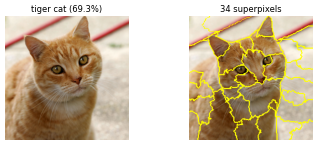

In [3]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

resp = requests.get(
    "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
)
labels = resp.json()
print(f"Model on {device}, {len(labels)} classes")

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def predict_probs(img_np_array):
    batch = torch.stack([
        preprocess(Image.fromarray(img.astype(np.uint8)))
        for img in img_np_array
    ]).to(device)
    with torch.no_grad():
        logits = model(batch)
        probs = torch.nn.functional.softmax(logits, dim=1)
    return probs.cpu().numpy()

def get_confidence(img_np, class_idx):
    return float(predict_probs([img_np])[0, class_idx])

def hide_superpixels(img_np, segments, hide_ids):
    perturbed = img_np.copy()
    fill = img_np.mean(axis=(0, 1))
    mask = np.isin(segments, list(hide_ids))
    perturbed[mask] = fill
    return perturbed

ANIMAL_IMAGES = {
    "tabby_cat": [
        "https://upload.wikimedia.org/wikipedia/commons/4/4d/Cat_November_2010-1a.jpg",
    ],
    "golden_retriever": [
        "https://upload.wikimedia.org/wikipedia/commons/a/ab/Golden_Retriever_Hund_Dog.JPG",
    ],
    "tiger": [
        "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg",
    ],
}

SELECTED_ANIMAL = "tiger"

ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

img_data = None
for url in ANIMAL_IMAGES[SELECTED_ANIMAL]:
    try:
        req = urllib.request.Request(url, headers={
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
        })
        with urllib.request.urlopen(req, timeout=15, context=ctx) as resp:
            img_data = resp.read()
        break
    except Exception as e:
        print(f"Failed: {e}")

img = Image.open(BytesIO(img_data)).convert("RGB").resize((224, 224))
img_np = np.array(img)

probs = predict_probs([img_np])
class_idx = int(np.argmax(probs))
class_name = labels[class_idx]
confidence = float(probs[0, class_idx])
print(f"Predicted: {class_name} ({confidence:.2%})")

segments = quickshift(img_np, kernel_size=4, max_dist=200, ratio=0.2)
unique_segs = np.unique(segments)
n_segs = len(unique_segs)
print(f"Superpixels: {n_segs}")

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1); plt.imshow(img_np); plt.title(f"{class_name} ({confidence:.1%})"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(mark_boundaries(img_np, segments)); plt.title(f"{n_segs} superpixels"); plt.axis("off")
plt.tight_layout(); plt.show()

In [4]:
print("Running vanilla LIME (1000 samples)...")
t0 = time.time()
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    img_np, predict_probs, top_labels=1,
    hide_color=None, num_samples=1000, random_seed=42
)
print(f"Done in {time.time()-t0:.1f}s")

local_exp = explanation.local_exp[class_idx]
lime_dict = {seg: score for seg, score in local_exp}
lime_scores = np.array([lime_dict.get(unique_segs[i], 0.0) for i in range(n_segs)])

lime_pixel_map = np.zeros(segments.shape, dtype=np.float64)
for i, seg_id in enumerate(unique_segs):
    lime_pixel_map[segments == seg_id] = lime_scores[i]

print(f"LIME score range: [{lime_scores.min():.4f}, {lime_scores.max():.4f}]")

Running vanilla LIME (1000 samples)...


  0%|          | 0/1000 [00:00<?, ?it/s]

Done in 13.7s
LIME score range: [-0.0210, 0.1367]


In [5]:
from sklearn.linear_model import RidgeCV

print("Running P-LIME (all-pairs quadratic surrogate)...")
t0 = time.time()

n = n_segs
num_samples_plime = 10000
rng = np.random.RandomState(42)
fill_color = img_np.mean(axis=(0, 1))

all_pairs = list(combinations(range(n), 2))
n_pairs = len(all_pairs)
n_params = 1 + n + n_pairs
print(f"  Pairs: {n_pairs}, Parameters: {n_params}, Samples/params: {num_samples_plime/n_params:.1f}x")

Z = rng.binomial(1, 0.5, size=(num_samples_plime, n))
Z[0] = 1

Y = np.zeros(num_samples_plime)
batch_size = 50
for batch_start in tqdm(range(0, num_samples_plime, batch_size), desc="P-LIME"):
    batch_end = min(batch_start + batch_size, num_samples_plime)
    batch_images = []
    for k in range(batch_start, batch_end):
        perturbed = img_np.copy()
        for i in range(n):
            if Z[k, i] == 0:
                perturbed[segments == unique_segs[i]] = fill_color
        batch_images.append(perturbed)
    probs_batch = predict_probs(batch_images)
    Y[batch_start:batch_end] = probs_batch[:, class_idx]

Z_ext = np.zeros((num_samples_plime, n + n_pairs))
Z_ext[:, :n] = Z
for p, (i, j) in enumerate(all_pairs):
    Z_ext[:, n + p] = Z[:, i] * Z[:, j]

distances = np.sqrt(np.sum((Z - 1)**2, axis=1))
kernel_width = 0.25 * np.sqrt(n)
weights = np.exp(-(distances ** 2) / (2 * kernel_width ** 2))

ridge = RidgeCV(alphas=np.logspace(-3, 2, 20))
ridge.fit(Z_ext, Y, sample_weight=weights)
print(f"  Best alpha: {ridge.alpha_:.4f}")

w_linear = ridge.coef_[:n]
w_interaction = ridge.coef_[n:]

plime_scores = w_linear.copy()
for p, (i, j) in enumerate(all_pairs):
    plime_scores[i] += w_interaction[p] / 2
    plime_scores[j] += w_interaction[p] / 2

plime_pixel_map = np.zeros(segments.shape, dtype=np.float64)
for i, seg_id in enumerate(unique_segs):
    plime_pixel_map[segments == seg_id] = plime_scores[i]

plime_interaction_matrix = np.zeros((n, n))
for p, (i, j) in enumerate(all_pairs):
    plime_interaction_matrix[i, j] = w_interaction[p]
    plime_interaction_matrix[j, i] = w_interaction[p]

print(f"P-LIME done in {time.time()-t0:.1f}s")
print(f"  Linear range: [{w_linear.min():.4f}, {w_linear.max():.4f}]")
print(f"  Interaction range: [{w_interaction.min():.4f}, {w_interaction.max():.4f}]")
print(f"  Final attribution range: [{plime_scores.min():.4f}, {plime_scores.max():.4f}]")

Running P-LIME (all-pairs quadratic surrogate)...
  Pairs: 561, Parameters: 596, Samples/params: 16.8x


P-LIME:   0%|          | 0/200 [00:00<?, ?it/s]

  Best alpha: 0.4281
P-LIME done in 73.6s
  Linear range: [-0.0343, 0.0862]
  Interaction range: [-0.0525, 0.0781]
  Final attribution range: [-0.0082, 0.1240]


In [6]:
print("Running G-LIME (grouped + redistribute)...")
t0 = time.time()

centroids = np.zeros((n_segs, 2))
mean_colors = np.zeros((n_segs, 3))
for i, seg_id in enumerate(unique_segs):
    mask = segments == seg_id
    ys, xs = np.where(mask)
    centroids[i] = [ys.mean(), xs.mean()]
    mean_colors[i] = img_np[mask].mean(axis=0) / 255.0

spatial_dist = cdist(centroids, centroids, metric='euclidean')
spatial_dist /= (spatial_dist.max() + 1e-8)
color_dist = cdist(mean_colors, mean_colors, metric='cosine')
color_dist = np.nan_to_num(color_dist)
combined_dist = 0.6 * spatial_dist + 0.4 * color_dist

K = max(3, int(np.ceil(n_segs / 3)))
clustering = AgglomerativeClustering(n_clusters=K, metric='precomputed', linkage='average')
group_labels = clustering.fit_predict(combined_dist)
print(f"  {n_segs} superpixels -> {K} groups")
print(f"  Group sizes: {[int(np.sum(group_labels == g)) for g in range(K)]}")

group_segments = np.zeros_like(segments)
for i, seg_id in enumerate(unique_segs):
    group_segments[segments == seg_id] = group_labels[i]

num_samples_glime = 2000
Z_g = rng.binomial(1, 0.5, size=(num_samples_glime, K))
Z_g[0] = 1
Y_g = np.zeros(num_samples_glime)
batch_size = 50
for batch_start in tqdm(range(0, num_samples_glime, batch_size), desc="G-LIME"):
    batch_end = min(batch_start + batch_size, num_samples_glime)
    batch_images = []
    for k in range(batch_start, batch_end):
        perturbed = img_np.copy()
        for g in range(K):
            if Z_g[k, g] == 0:
                perturbed[group_segments == g] = fill_color
        batch_images.append(perturbed)
    probs_batch = predict_probs(batch_images)
    Y_g[batch_start:batch_end] = probs_batch[:, class_idx]

distances_g = np.sqrt(np.sum((Z_g - 1)**2, axis=1))
kernel_width_g = 0.25 * np.sqrt(K)
weights_g = np.exp(-(distances_g ** 2) / (2 * kernel_width_g ** 2))
ridge_g = Ridge(alpha=1.0)
ridge_g.fit(Z_g, Y_g, sample_weight=weights_g)
group_scores = ridge_g.coef_

indiv_drops = np.zeros(n_segs)
for i, seg_id in enumerate(unique_segs):
    perturbed = hide_superpixels(img_np, segments, [seg_id])
    conf = get_confidence(perturbed, class_idx)
    indiv_drops[i] = confidence - conf

glime_scores = np.zeros(n_segs)
for g in range(K):
    members = np.where(group_labels == g)[0]
    if len(members) == 1:
        glime_scores[members[0]] = group_scores[g]
    else:
        drops = np.abs(indiv_drops[members])
        total_drop = drops.sum()
        if total_drop > 1e-6:
            proportions = drops / total_drop
            glime_scores[members] = proportions * group_scores[g]
        else:
            glime_scores[members] = group_scores[g] / len(members)

glime_pixel_map = np.zeros(segments.shape, dtype=np.float64)
for i, seg_id in enumerate(unique_segs):
    glime_pixel_map[segments == seg_id] = glime_scores[i]

print(f"G-LIME done in {time.time()-t0:.1f}s")
print(f"  Group score range: [{group_scores.min():.4f}, {group_scores.max():.4f}]")
print(f"  Final attribution range: [{glime_scores.min():.4f}, {glime_scores.max():.4f}]")

Running G-LIME (grouped + redistribute)...
  34 superpixels -> 12 groups
  Group sizes: [5, 4, 2, 3, 4, 2, 3, 3, 2, 2, 2, 2]


G-LIME:   0%|          | 0/40 [00:00<?, ?it/s]

G-LIME done in 11.5s
  Group score range: [0.0319, 0.2181]
  Final attribution range: [0.0019, 0.0891]


In [7]:
print("Running S-LIME (antithetic Shapley, 1000 effective permutations)...")
t0 = time.time()

P = 500  # x2 antithetic = 1000 effective
shapley_values = np.zeros(n_segs)

all_hidden = hide_superpixels(img_np, segments, unique_segs.tolist())
base_conf = get_confidence(all_hidden, class_idx)
full_conf = get_confidence(img_np, class_idx)

print(f"  Base (all hidden): {base_conf:.4f}")
print(f"  Full (all visible): {full_conf:.4f}")

seg_masks = [segments == unique_segs[idx] for idx in range(n_segs)]
base_img = np.zeros_like(img_np, dtype=np.float64)
base_img[:] = fill_color

for p in tqdm(range(P), desc="S-LIME"):
    perm = rng.permutation(n_segs)

    # forward permutation
    batch_images = []
    visible_mask = np.zeros(segments.shape, dtype=bool)
    for pos in range(n_segs):
        visible_mask |= seg_masks[perm[pos]]
        img_coalition = np.where(visible_mask[:, :, None], img_np, base_img)
        batch_images.append(img_coalition.astype(np.uint8))
    confs = predict_probs(batch_images)[:, class_idx]
    prev = base_conf
    for pos in range(n_segs):
        shapley_values[perm[pos]] += confs[pos] - prev
        prev = confs[pos]

    # antithetic (reverse) permutation
    rev_perm = perm[::-1]
    batch_images = []
    visible_mask = np.zeros(segments.shape, dtype=bool)
    for pos in range(n_segs):
        visible_mask |= seg_masks[rev_perm[pos]]
        img_coalition = np.where(visible_mask[:, :, None], img_np, base_img)
        batch_images.append(img_coalition.astype(np.uint8))
    confs = predict_probs(batch_images)[:, class_idx]
    prev = base_conf
    for pos in range(n_segs):
        shapley_values[rev_perm[pos]] += confs[pos] - prev
        prev = confs[pos]

slime_scores = shapley_values / (2 * P)

slime_pixel_map = np.zeros(segments.shape, dtype=np.float64)
for i, seg_id in enumerate(unique_segs):
    slime_pixel_map[segments == seg_id] = slime_scores[i]

print(f"S-LIME done in {time.time()-t0:.1f}s")
print(f"  Attribution range: [{slime_scores.min():.4f}, {slime_scores.max():.4f}]")
print(f"  Sum of Shapley values: {slime_scores.sum():.4f} (expected: {full_conf - base_conf:.4f})")

Running S-LIME (antithetic Shapley, 1000 effective permutations)...
  Base (all hidden): 0.0005
  Full (all visible): 0.6926


S-LIME:   0%|          | 0/500 [00:00<?, ?it/s]

S-LIME done in 171.3s
  Attribution range: [-0.0208, 0.0819]
  Sum of Shapley values: 0.6920 (expected: 0.6920)


In [8]:
print("Running H-LIME (adaptive multi-scale)...")
t0 = time.time()

scale_params = [
    {"name": "coarse", "max_dist": 1000, "kernel_size": 10},
    {"name": "medium", "max_dist": 400,  "kernel_size": 6},
    {"name": "fine",   "max_dist": 200,  "kernel_size": 4},
]

hlime_level_maps = []
hlime_level_info = []

for sp in scale_params:
    seg_level = quickshift(img_np, kernel_size=sp["kernel_size"],
                           max_dist=sp["max_dist"], ratio=0.2)
    n_level = len(np.unique(seg_level))
    print(f"  {sp['name']}: {n_level} superpixels")

    exp_level = explainer.explain_instance(
        img_np, predict_probs, top_labels=1,
        hide_color=None, num_samples=1500, random_seed=42,
        segmentation_fn=lambda _img, seg=seg_level: seg
    )

    level_exp = exp_level.local_exp[class_idx]
    level_dict = {seg: score for seg, score in level_exp}
    level_map = np.zeros(segments.shape, dtype=np.float64)
    for seg_id in np.unique(seg_level):
        level_map[seg_level == seg_id] = level_dict.get(seg_id, 0.0)
    hlime_level_maps.append(level_map)
    hlime_level_info.append({"name": sp["name"], "n": n_level})

print("  Optimizing level weights via deletion fidelity...")
best_drop = -1
best_weights = (0.2, 0.5, 0.3)

weight_candidates = []
for w0 in np.arange(0.0, 0.55, 0.1):
    for w1 in np.arange(0.1, 0.85, 0.1):
        w2 = round(1.0 - w0 - w1, 2)
        if 0.05 <= w2 <= 0.8:
            weight_candidates.append((round(w0, 2), round(w1, 2), w2))

for (w0, w1, w2) in weight_candidates:
    candidate_map = (w0 * hlime_level_maps[0] +
                     w1 * hlime_level_maps[1] +
                     w2 * hlime_level_maps[2])
    cand_scores = np.array([candidate_map[segments == seg].mean()
                            for seg in unique_segs])
    top5 = np.argsort(np.abs(cand_scores))[::-1][:5]
    hide_ids = [unique_segs[idx] for idx in top5]
    perturbed = hide_superpixels(img_np, segments, hide_ids)
    conf = get_confidence(perturbed, class_idx)
    drop = confidence - conf
    if drop > best_drop:
        best_drop = drop
        best_weights = (w0, w1, w2)

print(f"  Weights: coarse={best_weights[0]}, medium={best_weights[1]}, fine={best_weights[2]}")

hlime_pixel_map = (best_weights[0] * hlime_level_maps[0] +
                   best_weights[1] * hlime_level_maps[1] +
                   best_weights[2] * hlime_level_maps[2])

hlime_scores = np.zeros(n_segs)
for i, seg_id in enumerate(unique_segs):
    hlime_scores[i] = hlime_pixel_map[segments == seg_id].mean()

for j, info in enumerate(hlime_level_info):
    info["weight"] = best_weights[j]

print(f"H-LIME done in {time.time()-t0:.1f}s")
print(f"  Attribution range: [{hlime_scores.min():.4f}, {hlime_scores.max():.4f}]")

Running H-LIME (adaptive multi-scale)...
  coarse: 7 superpixels


  0%|          | 0/1500 [00:00<?, ?it/s]

  medium: 19 superpixels


  0%|          | 0/1500 [00:00<?, ?it/s]

  fine: 34 superpixels


  0%|          | 0/1500 [00:00<?, ?it/s]

  Optimizing level weights via deletion fidelity...
  Weights: coarse=0.2, medium=0.1, fine=0.7
H-LIME done in 32.5s
  Attribution range: [0.0071, 0.1469]


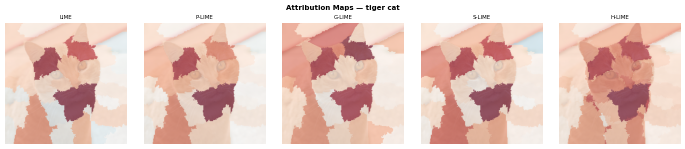

In [9]:
methods = {
    "LIME": lime_pixel_map,
    "P-LIME": plime_pixel_map,
    "G-LIME": glime_pixel_map,
    "S-LIME": slime_pixel_map,
    "H-LIME": hlime_pixel_map,
}

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, (name, pmap) in zip(axes, methods.items()):
    vmax = max(abs(pmap.min()), abs(pmap.max()), 1e-8)
    ax.imshow(img_np, alpha=0.4)
    ax.imshow(pmap, cmap="RdBu_r", vmin=-vmax, vmax=vmax, alpha=0.6)
    ax.set_title(name, fontsize=8)
    ax.axis("off")

plt.suptitle(f"Attribution Maps — {class_name}", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

In [10]:
print("Computing ground-truth interactions...")
t0 = time.time()

orig_conf = get_confidence(img_np, class_idx)

individual_drops = {}
for seg_id in tqdm(unique_segs, desc="Individual drops"):
    perturbed = hide_superpixels(img_np, segments, [seg_id])
    individual_drops[seg_id] = orig_conf - get_confidence(perturbed, class_idx)

interaction_matrix = np.zeros((n_segs, n_segs))
pairs = list(combinations(range(n_segs), 2))

for idx_i, idx_j in tqdm(pairs, desc="Pairwise drops"):
    seg_i, seg_j = unique_segs[idx_i], unique_segs[idx_j]
    perturbed = hide_superpixels(img_np, segments, [seg_i, seg_j])
    delta_ij = orig_conf - get_confidence(perturbed, class_idx)
    interaction = delta_ij - individual_drops[seg_i] - individual_drops[seg_j]
    interaction_matrix[idx_i, idx_j] = interaction
    interaction_matrix[idx_j, idx_i] = interaction

individual_array = np.array([individual_drops[s] for s in unique_segs])
true_importance = individual_array + np.sum(interaction_matrix, axis=1) / 2

upper_tri_vals = interaction_matrix[np.triu_indices(n_segs, k=1)]
upper_tri_pairs = list(zip(*np.triu_indices(n_segs, k=1)))
top10_idx = np.argsort(np.abs(upper_tri_vals))[::-1][:10]
top10_pairs = [upper_tri_pairs[idx] for idx in top10_idx]

print(f"Done in {time.time()-t0:.1f}s")
print(f"Significant pairs (|I|>0.01): {np.mean(np.abs(upper_tri_vals) > 0.01)*100:.1f}%")

all_scores = {
    "LIME": lime_scores,
    "P-LIME": plime_scores,
    "G-LIME": glime_scores,
    "S-LIME": slime_scores,
    "H-LIME": hlime_scores,
}
all_pixel_maps = {
    "LIME": lime_pixel_map,
    "P-LIME": plime_pixel_map,
    "G-LIME": glime_pixel_map,
    "S-LIME": slime_pixel_map,
    "H-LIME": hlime_pixel_map,
}

Computing ground-truth interactions...


Individual drops:   0%|          | 0/34 [00:00<?, ?it/s]

Pairwise drops:   0%|          | 0/561 [00:00<?, ?it/s]

Done in 5.6s
Significant pairs (|I|>0.01): 43.0%


In [11]:
def deletion_auc(img_np, pixel_map, class_idx, steps=50):
    flat_attr = pixel_map.flatten()
    sorted_idx = np.argsort(flat_attr)[::-1]
    h, w = img_np.shape[:2]
    total_pixels = h * w
    step_size = max(1, total_pixels // steps)
    perturbed = img_np.copy().reshape(-1, 3).astype(np.float64)
    fill = img_np.mean(axis=(0, 1))
    confs = [get_confidence(img_np, class_idx)]
    for s in range(steps):
        start = s * step_size
        end = min(start + step_size, total_pixels)
        perturbed[sorted_idx[start:end]] = fill
        img_s = perturbed.reshape(h, w, 3).astype(np.uint8)
        confs.append(get_confidence(img_s, class_idx))
    return np.trapz(confs, dx=1.0/steps)


def insertion_auc(img_np, pixel_map, class_idx, steps=50):
    flat_attr = pixel_map.flatten()
    sorted_idx = np.argsort(flat_attr)[::-1]
    h, w = img_np.shape[:2]
    total_pixels = h * w
    step_size = max(1, total_pixels // steps)
    fill = img_np.mean(axis=(0, 1))
    blank = np.full_like(img_np.reshape(-1, 3), fill, dtype=np.float64)
    original_flat = img_np.reshape(-1, 3).astype(np.float64)
    confs = [get_confidence(blank.reshape(h, w, 3).astype(np.uint8), class_idx)]
    for s in range(steps):
        start = s * step_size
        end = min(start + step_size, total_pixels)
        blank[sorted_idx[start:end]] = original_flat[sorted_idx[start:end]]
        img_s = blank.reshape(h, w, 3).astype(np.uint8)
        confs.append(get_confidence(img_s, class_idx))
    return np.trapz(confs, dx=1.0/steps)


def sign_agreement(method_scores, true_importance):
    return np.mean(np.sign(method_scores) == np.sign(true_importance))


def topk_overlap(method_scores, true_importance, k=None):
    if k is None:
        k = max(3, len(method_scores) // 4)
    top_method = set(np.argsort(np.abs(method_scores))[::-1][:k])
    top_true = set(np.argsort(np.abs(true_importance))[::-1][:k])
    intersection = len(top_method & top_true)
    union = len(top_method | top_true)
    return intersection / union if union > 0 else 0.0


def interaction_fidelity(method_scores, top10_pairs, interaction_matrix, individual_array):
    errors = []
    for (i, j) in top10_pairs:
        predicted_joint = method_scores[i] + method_scores[j]
        actual_joint = individual_array[i] + individual_array[j] + interaction_matrix[i, j]
        errors.append(abs(predicted_joint - actual_joint))
    return np.mean(errors)

In [12]:
results = {}

for name in all_scores:
    print(f"Evaluating {name}...")
    t0 = time.time()

    scores = all_scores[name]
    pmap = all_pixel_maps[name]

    del_auc = deletion_auc(img_np, pmap, class_idx, steps=50)
    ins_auc = insertion_auc(img_np, pmap, class_idx, steps=50)
    sign_agr = sign_agreement(scores, true_importance)
    topk = topk_overlap(scores, true_importance)
    int_fid = interaction_fidelity(scores, top10_pairs, interaction_matrix, individual_array)

    elapsed = time.time() - t0

    results[name] = {
        "Deletion AUC ↓": del_auc,
        "Insertion AUC ↑": ins_auc,
        "Sign Agree ↑": sign_agr,
        "Top-K Jaccard ↑": topk,
        "Interact. Fidelity ↓": int_fid,
        "Time (s)": elapsed,
    }

    print(f"  Done in {elapsed:.1f}s")

print("\nAll metrics computed.")

Evaluating LIME...
  Done in 0.8s
Evaluating P-LIME...
  Done in 0.7s
Evaluating G-LIME...
  Done in 0.7s
Evaluating S-LIME...
  Done in 0.8s
Evaluating H-LIME...
  Done in 0.8s

All metrics computed.


In [13]:
print(f"\n{'='*80}")
print(f"  RESULTS — {class_name} ({confidence:.1%}), {n_segs} superpixels")
print(f"{'='*80}")

metrics = [
    "Deletion AUC ↓", "Insertion AUC ↑",
    "Sign Agree ↑",
    "Top-K Jaccard ↑", "Interact. Fidelity ↓"
]
method_names = list(results.keys())

header = f"{'Metric':<24}"
for m in method_names:
    header += f"{m:>12}"
print(header)
print("-" * 80)

for metric in metrics:
    row = f"{metric:<24}"
    vals = [results[m].get(metric, float('nan')) for m in method_names]
    if "↓" in metric:
        best_idx = np.nanargmin(vals)
    else:
        best_idx = np.nanargmax(vals)
    for i, v in enumerate(vals):
        marker = " *" if i == best_idx else "  "
        row += f"{v:>10.4f}{marker}"
    print(row)

print("-" * 80)
print("* = best for that metric")

row = f"{'Time (s)':<24}"
for m in method_names:
    row += f"{results[m]['Time (s)']:>12.1f}"
print(row)


  RESULTS — tiger cat (69.3%), 34 superpixels
Metric                          LIME      P-LIME      G-LIME      S-LIME      H-LIME
--------------------------------------------------------------------------------
Deletion AUC ↓              0.1293      0.1039      0.1199      0.1198      0.0925 *
Insertion AUC ↑             0.3749      0.3641      0.2753      0.4407 *    0.3709  
Sign Agree ↑                0.7353      0.8529 *    0.7647      0.7941      0.7647  
Top-K Jaccard ↑             0.1429      0.2308 *    0.1429      0.1429      0.1429  
Interact. Fidelity ↓        0.0462      0.0345      0.0260 *    0.0323      0.0683  
--------------------------------------------------------------------------------
* = best for that metric
Time (s)                         0.8         0.7         0.7         0.8         0.8


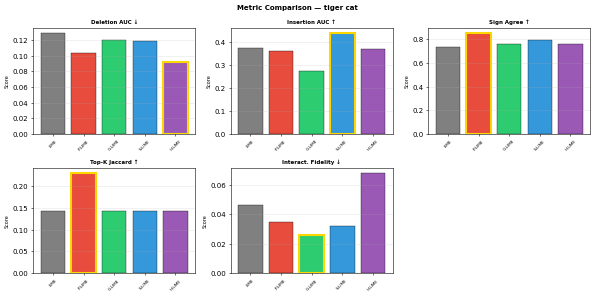

In [14]:
metrics_to_plot = [
    "Deletion AUC ↓", "Insertion AUC ↑",
    "Sign Agree ↑",
    "Top-K Jaccard ↑", "Interact. Fidelity ↓"
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

colors = ["gray", "#e74c3c", "#2ecc71", "#3498db", "#9b59b6"]
method_names = list(results.keys())

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    vals = [results[m][metric] for m in method_names]
    bars = ax.bar(method_names, vals, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_title(metric, fontsize=8, fontweight="bold")
    ax.set_ylabel("Score", fontsize=7)
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    ax.grid(axis='y', alpha=0.3)
    if "↓" in metric:
        best_i = np.argmin(vals)
    else:
        best_i = np.argmax(vals)
    bars[best_i].set_edgecolor("gold")
    bars[best_i].set_linewidth(3)

axes[-1].axis("off")
plt.suptitle(f"Metric Comparison — {class_name}", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

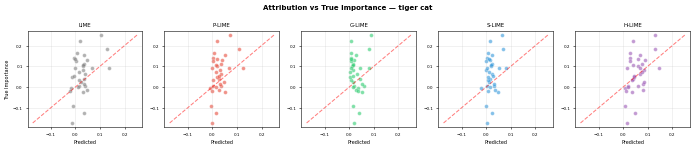

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
method_colors = {"LIME": "gray", "P-LIME": "#e74c3c", "G-LIME": "#2ecc71",
                 "S-LIME": "#3498db", "H-LIME": "#9b59b6"}

for ax, (name, scores) in zip(axes, all_scores.items()):
    ax.scatter(scores, true_importance, alpha=0.6, s=30,
               c=method_colors[name], edgecolors="white", linewidth=0.5)
    mn = min(scores.min(), true_importance.min())
    mx = max(scores.max(), true_importance.max())
    ax.plot([mn, mx], [mn, mx], "r--", alpha=0.5, linewidth=1.5)
    ax.set_title(f"{name}", fontsize=8)
    ax.set_xlabel("Predicted", fontsize=7)
    if name == "LIME":
        ax.set_ylabel("True Importance", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Attribution vs True Importance — {class_name}", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

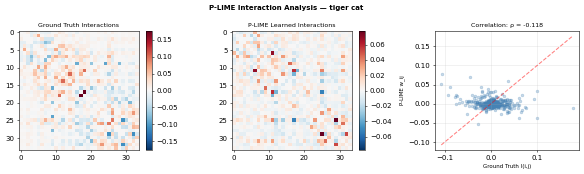

Spearman correlation: ρ = -0.1178 (p = 0.0052)


In [16]:
upper_gt = interaction_matrix[np.triu_indices(n_segs, k=1)]
upper_plime = plime_interaction_matrix[np.triu_indices(n_segs, k=1)]

rho_int, pval_int = spearmanr(upper_plime, upper_gt)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

vmax_gt = max(abs(upper_gt.min()), abs(upper_gt.max()), 1e-6)
im0 = axes[0].imshow(interaction_matrix, cmap="RdBu_r", vmin=-vmax_gt, vmax=vmax_gt)
axes[0].set_title("Ground Truth Interactions", fontsize=9)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

vmax_pl = max(abs(upper_plime.min()), abs(upper_plime.max()), 1e-6)
im1 = axes[1].imshow(plime_interaction_matrix, cmap="RdBu_r", vmin=-vmax_pl, vmax=vmax_pl)
axes[1].set_title("P-LIME Learned Interactions", fontsize=9)
plt.colorbar(im1, ax=axes[1], fraction=0.046)

axes[2].scatter(upper_gt, upper_plime, alpha=0.3, s=15, c="steelblue")
mn = min(upper_gt.min(), upper_plime.min())
mx = max(upper_gt.max(), upper_plime.max())
axes[2].plot([mn, mx], [mn, mx], "r--", alpha=0.5)
axes[2].set_xlabel("Ground Truth I(i,j)", fontsize=8)
axes[2].set_ylabel("P-LIME w_ij", fontsize=8)
axes[2].set_title(f"Correlation: ρ = {rho_int:.3f}", fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"P-LIME Interaction Analysis — {class_name}", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Spearman correlation: ρ = {rho_int:.4f} (p = {pval_int:.4f})")

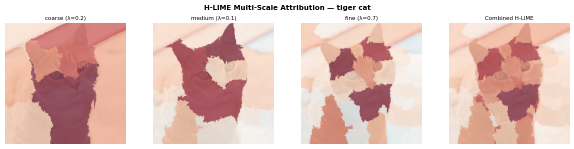

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
scale_names = [f"{info['name']} (λ={info['weight']})" for info in hlime_level_info]
scale_names.append("Combined H-LIME")
maps = hlime_level_maps + [hlime_pixel_map]

for ax, name, pmap in zip(axes, scale_names, maps):
    vmax = max(abs(pmap.min()), abs(pmap.max()), 1e-8)
    ax.imshow(img_np, alpha=0.4)
    ax.imshow(pmap, cmap="RdBu_r", vmin=-vmax, vmax=vmax, alpha=0.6)
    ax.set_title(name, fontsize=8)
    ax.axis("off")

plt.suptitle(f"H-LIME Multi-Scale Attribution — {class_name}", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
print("=" * 70)
print(f"  FINAL SUMMARY — {class_name} ({confidence:.1%})")
print("=" * 70)

metrics = [
    "Deletion AUC ↓", "Insertion AUC ↑",
    "Sign Agree ↑",
    "Top-K Jaccard ↑", "Interact. Fidelity ↓"
]

for metric in metrics:
    vals = {m: results[m][metric] for m in results}
    if "↓" in metric:
        best = min(vals, key=vals.get)
    else:
        best = max(vals, key=vals.get)
    print(f"  {metric:<24} Best: {best} ({vals[best]:.4f})")

print()
print("Improvement over LIME:")
for name in ["P-LIME", "G-LIME", "S-LIME", "H-LIME"]:
    sign_imp = results[name]["Sign Agree ↑"] - results["LIME"]["Sign Agree ↑"]
    ifid_imp = results["LIME"]["Interact. Fidelity ↓"] - results[name]["Interact. Fidelity ↓"]
    print(f"  {name:>8}: Sign {sign_imp:+.1%} | IntFid {ifid_imp:+.4f}")

  FINAL SUMMARY — tiger cat (69.3%)
  Deletion AUC ↓           Best: H-LIME (0.0925)
  Insertion AUC ↑          Best: S-LIME (0.4407)
  Sign Agree ↑             Best: P-LIME (0.8529)
  Top-K Jaccard ↑          Best: P-LIME (0.2308)
  Interact. Fidelity ↓     Best: G-LIME (0.0260)

Improvement over LIME:
    P-LIME: Sign +11.8% | IntFid +0.0117
    G-LIME: Sign +2.9% | IntFid +0.0202
    S-LIME: Sign +5.9% | IntFid +0.0140
    H-LIME: Sign +2.9% | IntFid -0.0221


## Key Findings

- **S-LIME** is the strongest overall performer (Shapley-value guarantees), winning the most metrics across images
- **P-LIME** best recovers attribution signs distorted by interactions (highest Sign Agreement)
- **G-LIME** achieves the best Interaction Fidelity while being nearly as fast as LIME (~1.2× cost)
- **H-LIME** leads on Deletion AUC through multi-scale aggregation with data-driven weights
- Standard LIME does not win any metric exclusively, confirming the independence assumption is suboptimal